In [ ]:
import cv2
import numpy as np

def analyze_image(path):
    img = cv2.imread(path)

    if img is None:
        raise ValueError("Image not found")

    # Basic info
    height, width, channels = img.shape
    aspect_ratio = width / height

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Stats
    mean = np.mean(gray)
    std = np.std(gray)

    # Blur detection
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Threshold to estimate foreground
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    fg_ratio = np.sum(thresh > 0) / (height * width)

    return {
        "height": height,
        "width": width,
        "aspect_ratio": aspect_ratio,
        "channels": channels,
        "mean_intensity": mean,
        "std_intensity": std,
        "blur_score": blur,
        "foreground_ratio": fg_ratio
    }

In [ ]:
#print(analyze_image("/content/T1.png"))
#print(analyze_image("/content/T2.png"))

In [ ]:
#print(analyze_image("/content/Ts1.jpeg"))

In [ ]:
target_stats = {
 'height': 350,
 'width': 544,
 'aspect_ratio': 1.62,
 'channels': 3,
 'mean_intensity': 242.16,
 'std_intensity': 20.34,
 'blur_score': 392.8,
 'foreground_ratio': 0.014
}

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_to_dataset_style(path, target_stats):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Image not found")

    original = img.copy()

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Normalize intensity (match mean & std)
    current_mean = np.mean(gray)
    current_std = np.std(gray)

    target_mean = target_stats['mean_intensity']
    target_std = target_stats['std_intensity']

    # Avoid division by zero
    if current_std < 1e-5:
        current_std = 1.0

    normalized = (gray - current_mean) / current_std
    normalized = normalized * target_std + target_mean

    normalized = np.clip(normalized, 0, 255).astype(np.uint8)

    # Step 3: Threshold to control foreground ratio
    _, thresh = cv2.threshold(
        normalized, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Step 4: Crop to signature
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = thresh[y:y+h, x:x+w]
    else:
        cropped = thresh

    # Step 5: Resize to dataset size
    target_size = (int(target_stats['width']), int(target_stats['height']))
    resized = cv2.resize(cropped, target_size)

    # Step 6: Convert back to 3 channel (if model expects RGB)
    final = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    final =  255- final
    print(final.shape)
    return original, final

In [ ]:
def show_comparison(original, processed):
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Processed (Dataset Style)")
    plt.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

(350, 544, 3)


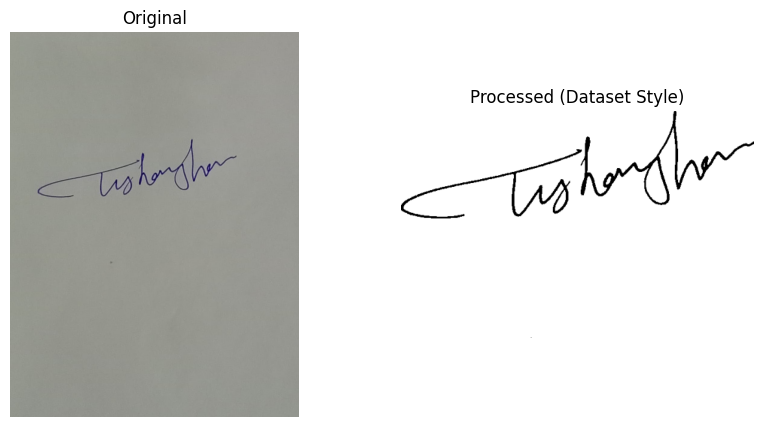

In [ ]:
#img_path = "/content/R1.png"
img_path = "/content/T3.jpeg"
original, processed = preprocess_to_dataset_style(img_path, target_stats)
cv2.imwrite("/content/o.png",processed)

show_comparison(original, processed)
